In [1]:
import sys
sys.path.append('..')
from experiment_utils import read_config_file, get_site_splits
from utils import get_project_dir
from eval_utils import compare_aligned_data

import numpy as np
import os
import rasterio

import sklearn.metrics
import seaborn as sns
import matplotlib.pyplot as plt


import pandas as pd
import seaborn as sns

In [2]:
# to get the different test sets
config_fp = '../experiment_configs/train_baseline_local_models.yaml'
cfg_hp_search = read_config_file(config_fp)
cfg_data = cfg_hp_search['data']
split_seed = cfg_data['split_seed']


In [3]:
project_dir = '..' #get_project_dir()
outputs_dir = '/n/tambe_lab/Everyone/tree_mapping/model_output'

resolution= 10
reference_maps = ['ETH', 'GLAD']
#models = [f'local_only_models/rf/{x}' for x in ['rf_3_channel', 'rf_4_channel', 'rf_12_channel', 'rf_15_channel']] + \
models = [f'local_only_models/128_filters/{x}' for x in ['3_channels', '4_channels', '12_channels', '15_channels']]
#models = [f'local_only_models/128_filters/{x}' for x in ['4_channels']]
#models = []

#pred padding is defined by how we cropped the satellite imagery to Karingani sites
pred_padding = 40

eval_metric = 'rmse'

In [4]:
# Aggregate predictions and calculate performance metrics

lidar_coarsened_dir = f'{project_dir}/data/int/lidar/lidar_by_site_32736_{resolution}m'
sites = sorted([x for x in os.listdir(lidar_coarsened_dir) if not x.startswith('.')])
results_by_site = {x: {} for x in reference_maps + models}
results_by_site_plot = []
results_aggregated = {x: {} for x in reference_maps + models}
results_by_split = {x: {} for x in reference_maps + models}

for model in models:
    labels = []
    preds = []
    model_output_dir = f'{outputs_dir}/{model}'
    for split_number in np.arange(4):
        labels_by_split = []
        preds_by_split = []
        test_sites = get_site_splits(split_seed, data_dir = '../data')[split_number]['test_sites']
        for site in test_sites:
            with rasterio.open(f'{lidar_coarsened_dir}/{site}/{site}_CHM_{resolution}m.tif') as file: # opens label tiff
                site_labels = file.read().ravel()
                labels = np.append(labels, site_labels)
                labels_by_split = np.append(labels_by_split, site_labels)

            with rasterio.open(f'{model_output_dir}/preds_{site}.tif') as file: # opens prediction tiff
                site_preds = file.read()[:,pred_padding:-pred_padding,pred_padding:-pred_padding].ravel()
                preds = np.append(preds, site_preds)
                preds_by_split = np.append(preds_by_split, site_preds)

            results_by_site[model][site] = compare_aligned_data(site_labels, site_preds)
    
        results_by_split[model][split_number] = compare_aligned_data(labels_by_split, preds_by_split)
    
    results_by_site_plot += [[results_by_site[model][site][eval_metric] for site in sites]]
    results_aggregated[model] = compare_aligned_data(labels, preds)
    
    
# get results
for reference_map in reference_maps:
    labels = []
    preds = []
    reference_map_by_site_dir = f'{project_dir}/data/existing_reference_data/{reference_map.lower()}_maps_per_site_{resolution}m'

    for split_number in np.arange(4):
        labels_by_split = []
        preds_by_split = []
        test_sites = get_site_splits(split_seed, data_dir = '../data')[split_number]['test_sites']
        for site in test_sites:
            with rasterio.open(f'{lidar_coarsened_dir}/{site}/{site}_CHM_{resolution}m.tif') as file: # opens label tiff
                site_labels = file.read().ravel()
                labels = np.append(labels, site_labels)
                labels_by_split = np.append(labels_by_split, site_labels)

            with rasterio.open(f'{reference_map_by_site_dir}/{reference_map}_MAP_{site}_{resolution}m.tif') as file: # opens prediction tiff
                site_preds = file.read().ravel()
                preds = np.append(preds, site_preds)
                preds_by_split = np.append(preds_by_split, site_preds)

            results_by_site[reference_map][site] = compare_aligned_data(site_labels, site_preds)
            
        results_by_split[reference_map][split_number] = compare_aligned_data(labels_by_split, preds_by_split)     
            
    results_by_site_plot += [[results_by_site[reference_map][site][eval_metric] for site in sites]]
    results_aggregated[reference_map] = compare_aligned_data(labels, preds)
    


In [5]:
# coalesce into pandas dataframes for plotting
results_keys = ['r2','mae','mse','rmse']
rows = []
for map_type, results_this_map_type in results_aggregated.items():
    results_this_type = {k: results_this_map_type[k] for k in results_keys}
    results_this_type.update({'map_type': map_type})
    rows.append(results_this_type)
results_agg_df = pd.DataFrame(rows)

rows = []
for map_type, results_this_map_type in results_by_split.items():
    for split, results_this_split in results_this_map_type.items():
        results_this_type = {k: results_this_split[k] for k in results_keys}
        results_this_type.update({'map_type': map_type, 'test_split': split})
        rows.append(results_this_type)
results_by_split_df = pd.DataFrame(rows)

rows = []
for map_type, results_this_map_type in results_by_site.items():
    for site, results_this_site in results_this_map_type.items():
        results_this_type = {k: results_this_site[k] for k in results_keys}
        results_this_type.update({'map_type': map_type, 'test_site': site})
        rows.append(results_this_type)
results_by_site_df = pd.DataFrame(rows)



/tmp/ipykernel_3644226/3039674441.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([label_names_dict[x.get_text()] for x in ax[0].get_xticklabels()],


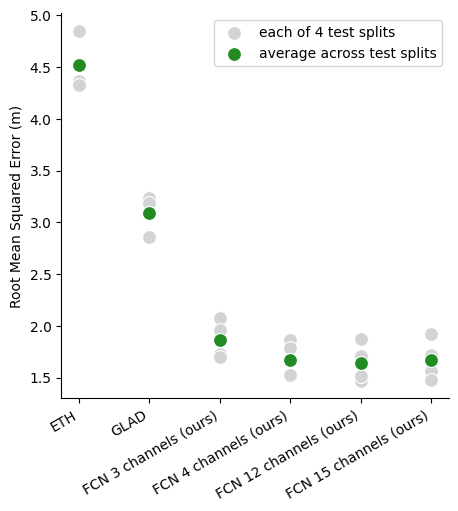

In [8]:
y_key = 'rmse'
metric_labels = {'mae': "Mean Absolute Error (m)", 'rmse': "Root Mean Squared Error (m)"}

label_names_dict = {'ETH':'ETH', 
                    'GLAD':'GLAD', 
                    'local_only_models/128_filters/3_channels': 'FCN 3 channels (ours)',
                   'local_only_models/128_filters/4_channels': 'FCN 4 channels (ours)',
                   'local_only_models/128_filters/12_channels': 'FCN 12 channels (ours)',
                   'local_only_models/128_filters/15_channels': 'FCN 15 channels (ours)'}
fig, ax = plt.subplots(1, figsize=(5,5), sharey=True)
ax = [ax]

sns.scatterplot(data=results_by_split_df, x='map_type',y=y_key, 
                s=100,
                color='lightgrey', label='each of 4 test splits',
               ax=ax[0])
sns.scatterplot(data=results_by_split_df.groupby('map_type')[[y_key]].mean(), x='map_type', y=y_key, 
                s=100,
                color='forestgreen', label='average across test splits',
               ax=ax[0])



ax[0].set_ylabel(metric_labels[y_key])
for i in range(len(ax)):
    ax[i].set_xlabel(None)

ax[0].set_xticklabels([label_names_dict[x.get_text()] for x in ax[0].get_xticklabels()], 
                      rotation=30, horizontalalignment='right')
sns.despine()

# condensed quantitative plot

/tmp/ipykernel_3644226/2105142783.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([label_names_dict[x.get_text()] for x in ax[0].get_xticklabels()],


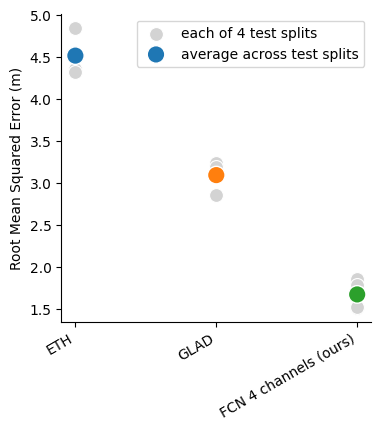

In [9]:
methods_compare = ['ETH', 'GLAD', 'local_only_models/128_filters/4_channels']
results_by_split_df_condensed = results_by_split_df[results_by_split_df['map_type'].apply(lambda x: x in methods_compare)]

y_key = 'rmse'
metric_labels = {'mae': "Mean Absolute Error (m)", 'rmse': "Root Mean Squared Error (m)"}

label_names_dict = {'ETH':'ETH', 
                    'GLAD':'GLAD', 
                    'local_only_models/128_filters/3_channels': 'FCN 3 channels (ours)',
                   'local_only_models/128_filters/4_channels': 'FCN 4 channels (ours)',
                   'local_only_models/128_filters/12_channels': 'FCN 12 channels (ours)',
                   'local_only_models/128_filters/15_channels': 'FCN 15 channels (ours)'}


fig, ax = plt.subplots(1, figsize=(4,4), sharey=True)
ax = [ax]

sns.scatterplot(data=results_by_split_df_condensed, x='map_type',y=y_key, 
                s=100,
                color='lightgrey', label='each of 4 test splits',
               ax=ax[0])
sns.scatterplot(data=results_by_split_df_condensed.groupby('map_type')[[y_key]].mean(), x='map_type', y=y_key, 
                s=160,
                c=sns.color_palette("tab10")[:3],
                label='average across test splits',
               ax=ax[0])



ax[0].set_ylabel(metric_labels[y_key])
for i in range(len(ax)):
    ax[i].set_xlabel(None)

ax[0].set_xticklabels([label_names_dict[x.get_text()] for x in ax[0].get_xticklabels()], 
                      rotation=30, horizontalalignment='right')
sns.despine()

/tmp/ipykernel_3644226/3591264680.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=80);


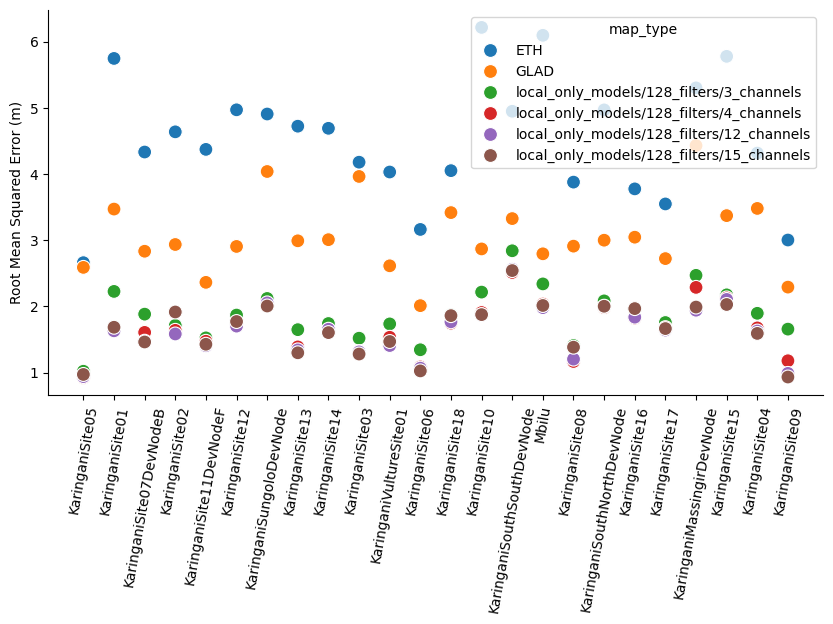

In [10]:
y_key = 'rmse'
metric_labels = {'mae': "Mean Absolute Error (m)", "rmse":'Root Mean Squared Error (m)' }
fig, ax = plt.subplots(1, figsize=(10,5), sharey=True)
ax = [ax]
sns.scatterplot(data=results_by_site_df, x='test_site',y=y_key, 
                s=100,
                hue='map_type',
               # color='lightgrey', label='each of 24 test sites',
               ax=ax[0])


ax[0].set_ylabel(metric_labels[y_key])
for i in range(len(ax)):
    ax[i].set_xlabel(None)

sns.despine()

ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=80);

# Visualize predictions


In [11]:
model = 'local_only_models/128_filters/4_channels'
model_output_dir = f'{outputs_dir}/{model}'
existing_maps_dir = f'../../tree_mapping/data/existing_reference_data'

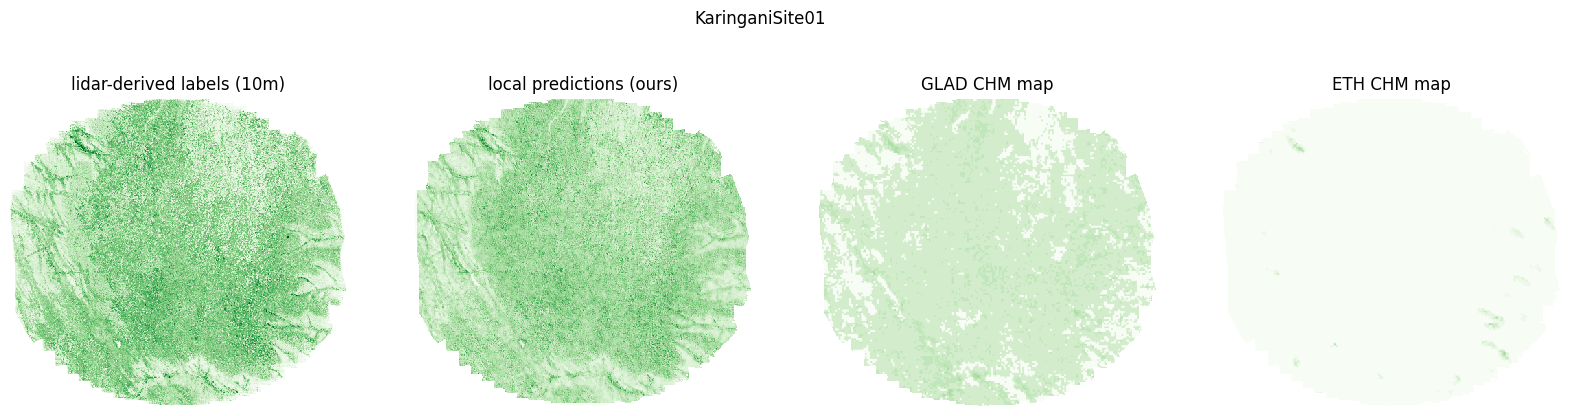

In [12]:
plot_sites = ['KaringaniSite01']

for site in plot_sites:
    with rasterio.open(f'{lidar_coarsened_dir}/{site}/{site}_CHM_{resolution}m.tif') as file: # opens label tiff
        site_labels = file.read()[0]

    with rasterio.open(f'{model_output_dir}/preds_{site}.tif') as file: # opens prediction tiff
        site_preds = file.read()[0,pred_padding:-pred_padding,pred_padding:-pred_padding]
        
    with rasterio.open(f'{existing_maps_dir}/glad_maps_per_site_{resolution}m/GLAD_MAP_{site}_{resolution}m.tif') as file: # opens prediction tiff
        glad_preds = file.read()[0]#,pred_padding:-pred_padding,pred_padding:-pred_padding]
        
    with rasterio.open(f'{existing_maps_dir}/eth_maps_per_site_{resolution}m/ETH_MAP_{site}_{resolution}m.tif') as file: # opens prediction tiff
        eth_preds = file.read()[0]#,pred_padding:-pred_padding,pred_padding:-pred_padding]
        
    map_labels = [f'lidar-derived labels ({resolution}m)',
                  'local predictions (ours)',
                  'GLAD CHM map',
                  'ETH CHM map'
                 ]
                  
    maps_to_print = [x.copy() for x in [site_labels, site_preds, glad_preds, eth_preds]]
    mask = site_labels < 0
    for x in maps_to_print:
        x[mask] = np.nan

    fig, ax = plt.subplots(1,len(maps_to_print),figsize=(len(maps_to_print)*5,5))
    for i, map_to_print in enumerate(maps_to_print):
        ax[i].imshow(map_to_print, vmin=0, vmax=15, cmap='Greens', interpolation='none')
        ax[i].set_title(map_labels[i])
    

    for axis in ax:
        axis.axis('off')
    
    fig.suptitle(site)

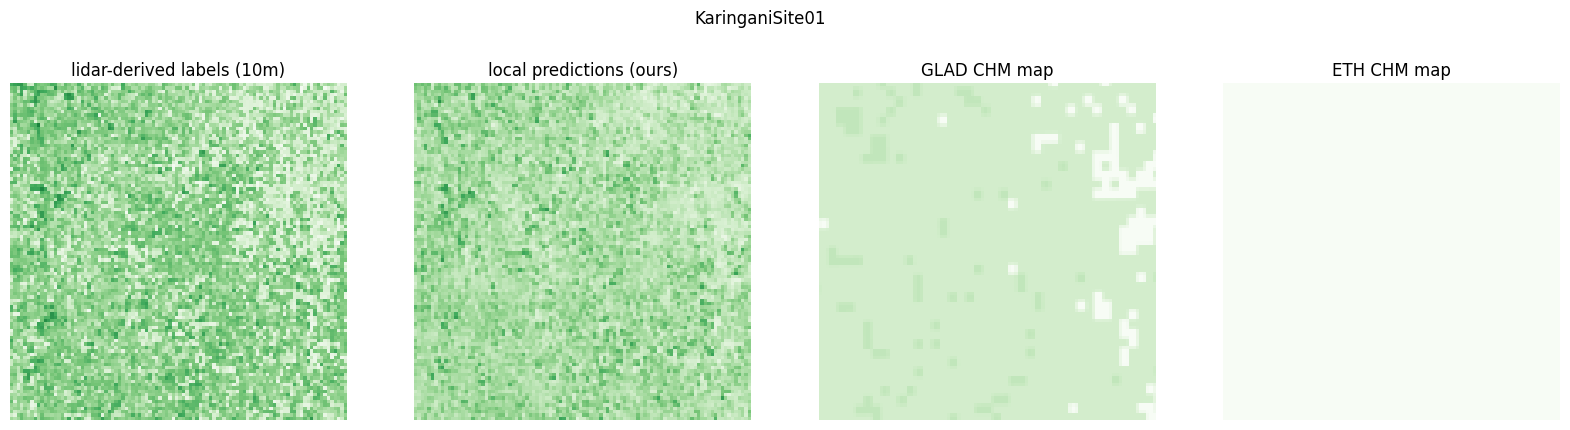

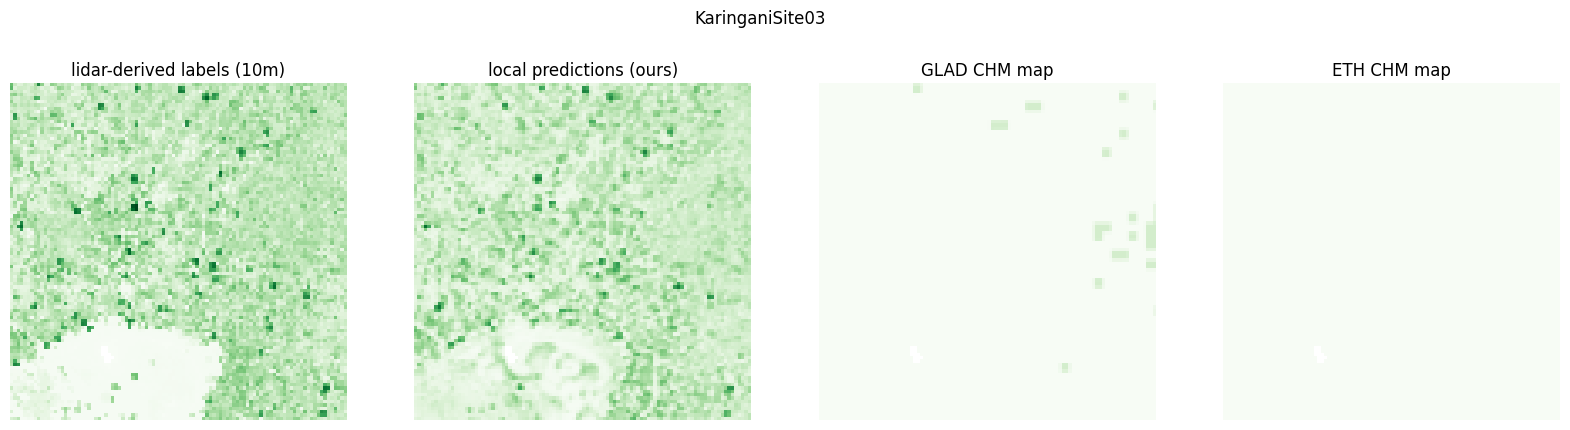

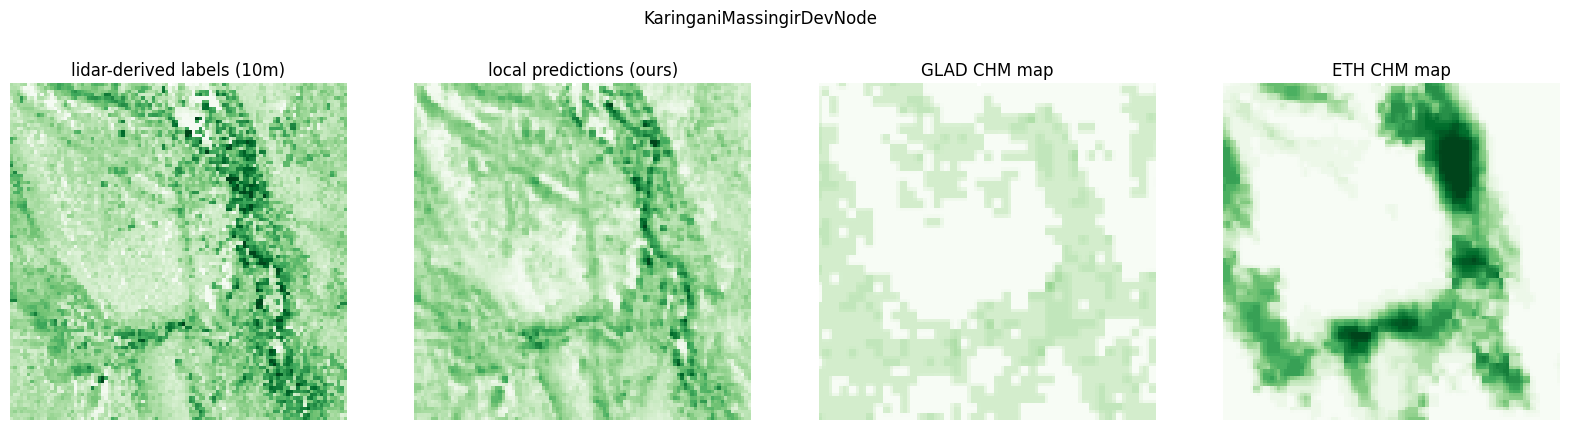

In [13]:
plot_sites = ['KaringaniSite01', 'KaringaniSite03', 'KaringaniMassingirDevNode']

x1, x2, y1,y2 = 200,300,100,200

for site in plot_sites:
    with rasterio.open(f'{lidar_coarsened_dir}/{site}/{site}_CHM_{resolution}m.tif') as file: # opens label tiff
        site_labels = file.read()[0][y1:y2,x1:x2]

    with rasterio.open(f'{model_output_dir}/preds_{site}.tif') as file: # opens prediction tiff
        site_preds = file.read()[0,pred_padding:-pred_padding,pred_padding:-pred_padding][y1:y2,x1:x2]
        
    with rasterio.open(f'{existing_maps_dir}/glad_maps_per_site_{resolution}m/GLAD_MAP_{site}_{resolution}m.tif') as file: # opens prediction tiff
        glad_preds = file.read()[0][y1:y2,x1:x2]
        
    with rasterio.open(f'{existing_maps_dir}/eth_maps_per_site_{resolution}m/ETH_MAP_{site}_{resolution}m.tif') as file: # opens prediction tiff
        eth_preds = file.read()[0][y1:y2,x1:x2]
        
    map_labels = [f'lidar-derived labels ({resolution}m)',
                  'local predictions (ours)',
                  'GLAD CHM map',
                  'ETH CHM map'
                 ]
                  
    maps_to_print = [x.copy() for x in [site_labels, site_preds, glad_preds, eth_preds]]
    mask = site_labels < 0
    for x in maps_to_print:
        x[mask] = np.nan

    fig, ax = plt.subplots(1,len(maps_to_print),figsize=(len(maps_to_print)*5,5))
    for i, map_to_print in enumerate(maps_to_print):
        ax[i].imshow(map_to_print, vmin=0, vmax=15, cmap='Greens', interpolation='none')
        ax[i].set_title(map_labels[i])
    

    for axis in ax:
        axis.axis('off')
    
    fig.suptitle(site)